In [1]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents.format_scratchpad.openai_tools import (
    format_to_openai_tool_messages,
)
from langchain.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser
from langchain.agents import AgentExecutor
from tools.molecular_dynamics import (
    MDSimulationNVETool,
    MDSimulationNVTTool,
    MDSimulationNPTTool,
)

In [2]:
OPENAI_API = os.getenv("OPENAI_API")
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0, api_key=OPENAI_API)

tools = [
    MDSimulationNVETool(),
    MDSimulationNVTTool(),
    MDSimulationNPTTool()
]
MEMORY_KEY = "chat_history"
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are tasked with performing molecular dynamics (MD) simulations using predefined tools.
You can perform MD simulations under 3 conditions: NVE (constant energy), NVT (constant temperature) and NPT (constant pressure and temperature).
For initializing atomic system without cif file, if lattice parameters are not given select appropiate values for the lattice parameters
and mention it explicitly to the user. For cubic crystal systems make sure that a=b=c when initializing lattice structures. All temperature
inputs to functions are in Kelvin so convert temperature if needed according before passing to the tools.
            """
            
        ),
        MessagesPlaceholder(variable_name=MEMORY_KEY),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ]
)
llm_with_tools = llm.bind_tools(tools)

agent = (
    {
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: format_to_openai_tool_messages(
            x["intermediate_steps"]
        ),
        "chat_history": lambda x: x["chat_history"],
    }
    | prompt
    | llm_with_tools
    | OpenAIToolsAgentOutputParser()
)

agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)



> Entering new None chain...

Invoking: `MDSImulationNVTTool` with `{'cif_file': 'crystallm_cifs/Ni3Al_20241130_101842/generated_cifs/sample_1.cif', 'name': 'Ni3Al', 'potential_type': 'emt', 'temperature': 550, 'num_md_steps': 100000, 'num_interval': 1000}`


log_filename =  md_simulation_results/MD_20241213_144137/nvt.log
traj_filename =  md_simulation_results/MD_20241213_144137/nvt.traj
    imd     Etot(eV)    T(K)    stress(mean,xx,yy,zz,yz,xz,xy)(GPa)  elapsed_time(sec)
    0   59.803    569.63    -1.31  6.59  -5.20  -5.32  -0.08  0.01  0.01    0.018
  1000   36.972    549.37    2.92  2.72  2.91  3.13  0.23  -0.31  -0.16    4.749
  2000   33.923    548.33    3.21  2.69  3.73  3.22  0.86  -0.14  -0.25    9.432
  3000   33.182    552.25    2.66  2.90  2.77  2.32  0.33  -0.03  0.76    14.334
  4000   31.695    553.18    3.04  2.64  3.22  3.27  -0.36  -0.04  0.43    20.862
  5000   30.996    553.70    2.50  2.37  2.22  2.90  -0.66  0.16  -0.29    36.859
  6000   32.841    546.28    2

c:\Akshat\CMU\Academic\Fall 2024\research\alloy-gen\tools\molecular_dynamics.py:318: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


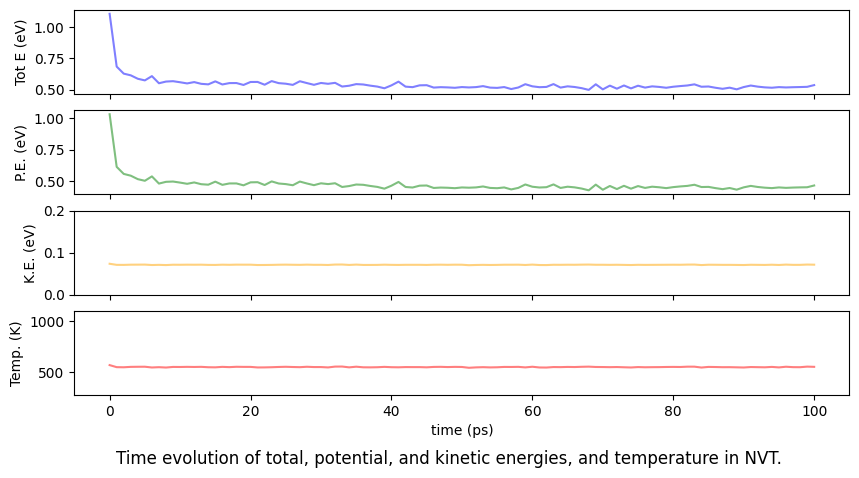

NoneThe molecular dynamics simulation of Ni₃Al under NVT conditions using the EMT potential has been initiated. The simulation is set to run for 100,000 steps with an initial temperature of 550 K.

> Finished chain.


In [3]:
input = """
Perform a molecular dynamics simulation of Ni3Al under constant number of particles, volume, and temperature (NVT) 
conditions using the Effective Medium Theory (EMT) potential. Initialize the system from the provided CIF file for Ni₃Al
at ("crystallm_cifs/Ni3Al_20241130_101842/generated_cifs/sample_1.cif"). 
Set the initial temperature to 550 K and run the simulation for 100,000 steps. Use the EMT potential to model the 
interatomic interactions for Ni3Al and control the temperature using the Langevin thermostat.
"""

atoms = list(agent_executor.stream({"input": input, "chat_history":[]}))



> Entering new None chain...

Invoking: `MDSimulationNVETool` with `{'name': 'Al', 'crystalstructure': 'fcc', 'a': 4.05, 'temperature': 933.15, 'num_md_steps': 100000, 'potential_type': 'emt'}`


log_filename =  md_simulation_results/MD_20241213_204234/nve.log
traj_filename =  md_simulation_results/MD_20241213_204234/nve.traj

    imd     Etot(eV)    Ekin(eV)    Epot(eV)    T(K)
     0     3.596784526     3.637339811    -0.040555285   1042.21
   1000     3.597238248     1.212560806    2.384677442   347.44
   2000     3.597092115     2.392710450    1.204381665   685.59
   3000     3.597097883     1.886498998    1.710598885   540.54
   4000     3.597126439     1.942361267    1.654765172   556.55
   5000     3.597275968     1.658861358    1.938414611   475.32
   6000     3.597213508     1.740283102    1.856930406   498.65
   7000     3.596959238     2.305251362    1.291707876   660.53
   8000     3.597216173     1.789773454    1.807442719   512.83
   9000     3.597178762     1.646210419

c:\Akshat\CMU\Academic\Fall 2024\research\alloy-gen\tools\molecular_dynamics.py:221: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(log_filename, delim_whitespace=True)


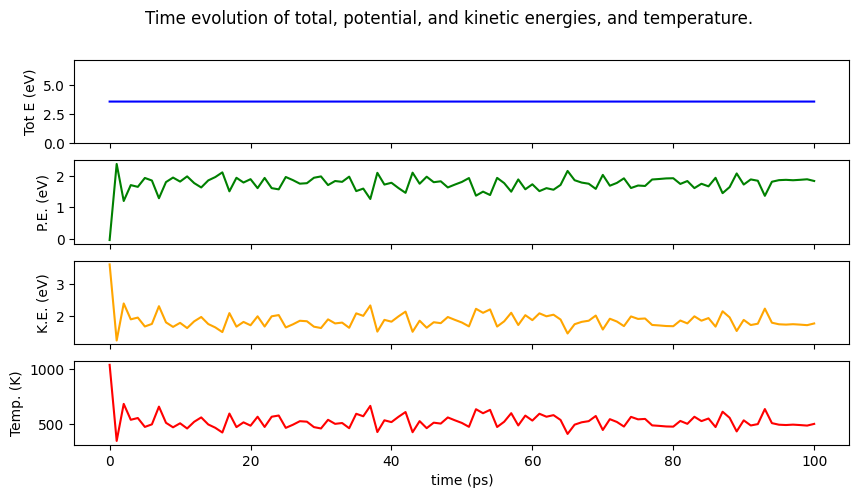

NoneThe molecular dynamics simulation of aluminum (Al) under constant energy (NVE) conditions using the Effective Medium Theory (EMT) potential has been initiated. The system is initialized with a face-centered cubic (FCC) crystal structure with a lattice constant of 4.05 Å. The temperature is set to 660°C (933.15 K), and the simulation will run for 100,000 steps. The EMT potential is used to model interatomic interactions for aluminum.

> Finished chain.


In [3]:
input = """
Perform a molecular dynamics simulation of aluminum (Al) under constant energy (NVE) conditions 
using the Effective Medium Theory (EMT) potential. The system should be initialized with a 
face-centered cubic (FCC) crystal structure, using a lattice constant of 4.05. Set the temperature
 to 660 C and run the simulation for 100000 steps. Use the EMT potential 
 to model interatomic interactions for aluminum. 
"""

atoms = list(agent_executor.stream({"input": input, "chat_history":[]}))



> Entering new None chain...

Invoking: `MDSimulationNPTTool` with `{'name': 'Cu', 'crystalstructure': 'fcc', 'cubic': True, 'potential_type': 'emt', 'temperature': 300, 'num_md_steps': 20000, 'sigma': 1, 'ttime': 20}`


log_filename =  md_simulation_results/MD_20241213_145619/npt.log
traj_filename =  md_simulation_results/MD_20241213_145619/npt.traj
    imd     Etot(eV)    T(K)    stress(mean,xx,yy,zz,yz,xz,xy)(GPa)  elapsed_time(sec)
  1000   6.771    303.67    0.49  0.39  0.75  0.31  -0.52  0.10  -0.28    30.708
  2000   7.155    270.35    0.83  0.80  0.75  0.95  -0.47  -0.06  0.01    60.789
  3000   8.073    289.94    0.59  0.99  0.44  0.35  -0.48  -0.11  -0.13    90.761
  4000   9.060    370.54    0.43  0.52  0.54  0.23  -0.49  0.44  -0.04    120.766
  5000   8.630    305.99    -0.38  -0.73  -0.40  0.00  -0.66  0.07  0.03    151.014
  6000   7.778    314.51    -0.60  -0.96  -0.85  0.01  -0.52  0.02  0.16    181.215
  7000   7.459    297.79    -0.63  -0.69  -0.62  -0.57  -0.70  0

c:\Akshat\CMU\Academic\Fall 2024\research\alloy-gen\tools\molecular_dynamics.py:429: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


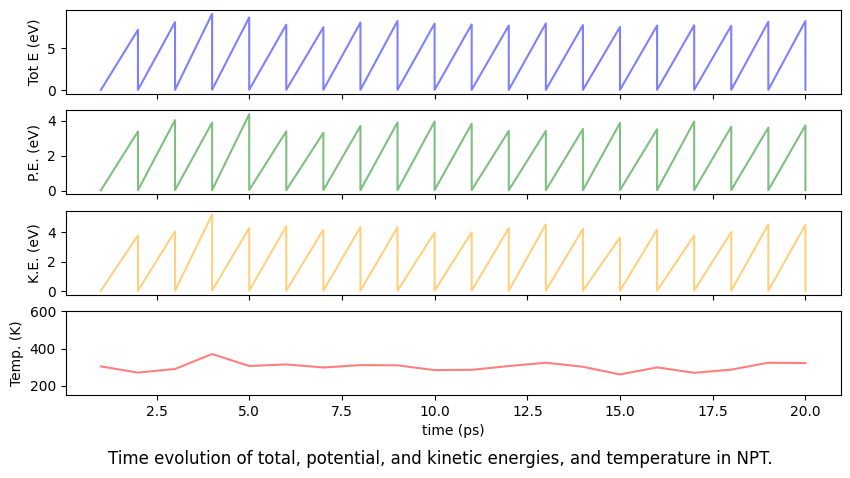

NoneThe molecular dynamics simulation of cubic copper (Cu) under constant pressure and temperature (NPT) conditions using the Effective Medium Theory (EMT) potential has been initiated. The system is initialized with a face-centered cubic (FCC) crystal structure for Cu, with the initial temperature set to 300 K and the pressure set to 1 bar. The simulation will run for 20,000 steps.

> Finished chain.


In [5]:
input = """
Perform a molecular dynamics simulation of cubic copper (Cu) under constant pressure and temperature (NPT) conditions 
using the Effective Medium Theory (EMT) potential. Initialize the system with a face-centered cubic (FCC) crystal
 structure for Cu. Set the initial temperature to 300 K and the pressure to 1 bar. 
 Use the Nose-Hoover thermostat and barostat to control temperature and pressure, respectively. Run the simulation for 20,000 steps
"""

atoms = list(agent_executor.stream({"input": input, "chat_history":[]}))